# ZEPTAT SE PEPY
- jaky je problem s Batchnorm

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [29]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src.plotting_styles import apply_global_style

In [30]:
from src.load_sam_data import load_dataset

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)

zero_pts = []
for idx, data in enumerate(full_dataset):
    if data.any() == np.zeros(96).any(): 
        zero_pts.append(idx)

dataset = np.delete(full_dataset, zero_pts, axis=0)

..\data\FJ\FI01X1\FI01X1_ch


In [31]:
from src.autoencoders import prepocess_data

dataset = prepocess_data(dataset)

In [32]:
len(dataset)

612

In [33]:
import torch.nn as nn

# first model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(96, 64),  
            nn.ReLU(),

            nn.Linear(64, 32),  
            nn.ReLU(),
            
            nn.Linear(32, 16),  
            nn.Sigmoid(),
            )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            
            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 96),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [34]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [35]:
batch_size = 32
torch_small_df = HistDataset(dataset)
dataloader = DataLoader(torch_small_df, batch_size=batch_size, shuffle=False)

ae_conv = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.001)

In [36]:
batch = next(iter(dataloader))

# Ak dataloader vracia dvojicu (X, y)
data = batch 
print(data.shape)

torch.Size([32, 1, 96])


In [37]:
from src.autoencoders import train_ae

ae_conv.train()
losses, ae_conv = train_ae(n_epochs=40, dataloader=dataloader, model=ae_conv, optimizer=optimizer, criterion=criterion)

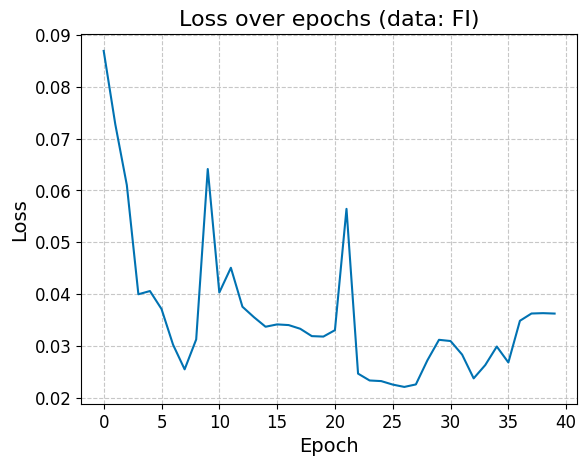

In [38]:
apply_global_style()
plt.title("Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(losses)), losses)
plt.show()

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


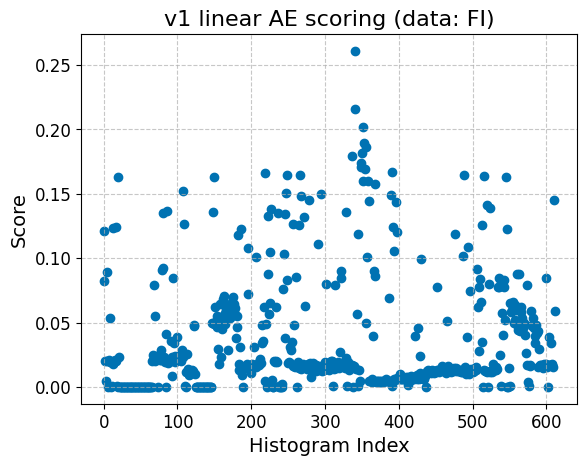

In [39]:
from src.autoencoders import eval_and_plot_score
apply_global_style()
plt.title("v1 linear AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")
score = eval_and_plot_score(model=ae_conv, dataloader=dataloader, criterion=criterion)

Locating outliers same as kNN and OCSVM but not discovering point 363 (which may or may not be considered)

In [40]:
outliers = np.where(np.array(score) > 0.15)
outliers

(array([ 20, 108, 150, 218, 247, 248, 266, 337, 340, 341, 348, 349, 350,
        351, 352, 353, 354, 355, 358, 367, 390, 488, 515, 545]),)

In [41]:
dataset[5]

tensor([0.1381, 0.1186, 0.1315, 0.1413, 0.1768, 0.1387, 0.1649, 0.1626, 0.1744,
        0.1603, 0.1942, 0.1841, 0.2262, 0.1822, 0.2209, 0.2245, 0.1987, 0.2190,
        0.2084, 0.2175, 0.2041, 0.2179, 0.2153, 0.2804, 0.2179, 0.2201, 0.2270,
        0.2488, 0.2652, 0.2535, 0.2370, 0.2504, 0.2372, 0.2172, 0.2288, 0.2247,
        0.2315, 0.2143, 0.2192, 0.2207, 0.2471, 0.2452, 0.2584, 0.2505, 0.2353,
        0.2456, 0.1948, 0.1963, 0.1944, 0.2017, 0.1857, 0.1903, 0.1908, 0.1665,
        0.1756, 0.1571, 0.1593, 0.1748, 0.1636, 0.1676, 0.1484, 0.1448, 0.1609,
        0.1810, 0.1557, 0.1325, 0.1378, 0.1374, 0.1229, 0.1607, 0.1320, 0.1109,
        0.1120, 0.1104, 0.0792, 0.0983, 0.0838, 0.0701, 0.0902, 0.0956, 0.2500,
        0.0000, 0.0000, 0.0000, 0.0263, 0.0840, 0.0300, 0.0506, 0.0536, 0.0290,
        0.0513, 0.0667, 0.0741, 0.0263, 0.1463, 0.1739])

In [42]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(dataset):
        pred = ae_conv(data).numpy()
         
        for p in preds:
            if pred.all() == p.all():
                break
        else:
            print(idx)
            preds.append(pred)

0


In [43]:
dataset[15]

tensor([0.2348, 0.2655, 0.2324, 0.2869, 0.3821, 0.3514, 0.3548, 0.3875, 0.4060,
        0.3515, 0.3518, 0.4512, 0.4743, 0.4317, 0.4406, 0.5151, 0.5004, 0.5033,
        0.4622, 0.4772, 0.5020, 0.4966, 0.5479, 0.5158, 0.5191, 0.5347, 0.5924,
        0.5583, 0.5418, 0.5501, 0.5355, 0.5337, 0.5158, 0.5133, 0.5126, 0.4947,
        0.5169, 0.4881, 0.4990, 0.5189, 0.5542, 0.5843, 0.5645, 0.5776, 0.5347,
        0.4701, 0.4685, 0.4386, 0.4674, 0.4801, 0.4647, 0.4183, 0.4235, 0.4372,
        0.4224, 0.4114, 0.3782, 0.3798, 0.3735, 0.3592, 0.3569, 0.3533, 0.3662,
        0.3891, 0.3847, 0.3581, 0.3177, 0.3129, 0.3212, 0.2705, 0.2549, 0.2824,
        0.2500, 0.2221, 0.2164, 0.2005, 0.2391, 0.2048, 0.1541, 0.1783, 0.2500,
        0.1250, 0.1111, 0.0000, 0.1053, 0.1832, 0.1000, 0.1266, 0.1071, 0.1159,
        0.2137, 0.0833, 0.1111, 0.0789, 0.1951, 0.1304])

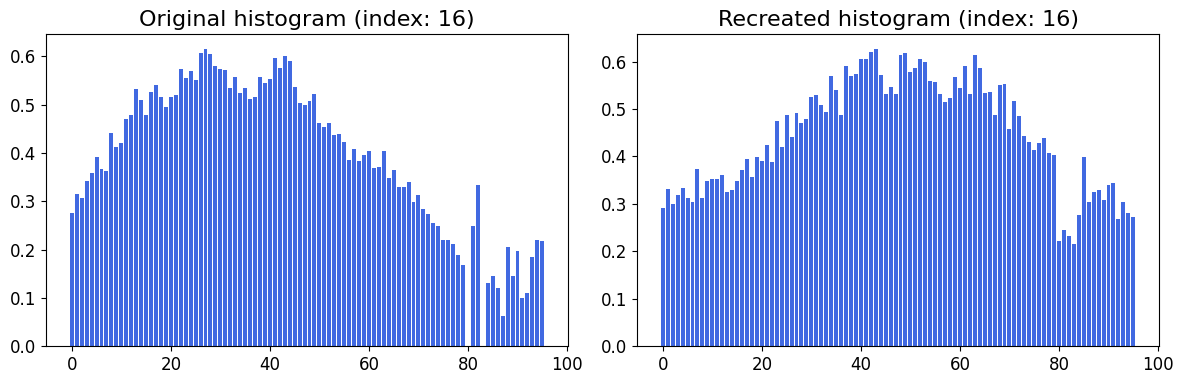

In [44]:
idx = 16

ae_conv.eval()
pred = ae_conv(dataset[idx]).detach().numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), dataset[idx], zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
#axes[0].grid(True, linestyle='--', alpha=0.7, zorder=-2)

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
#axes[1].grid(True, linestyle='--', alpha=0.7, zorder=-2)

plt.tight_layout()
plt.show()

In [45]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [340, 341, 351, 353, 355, 350, 337, 349, 348, 354]
lowest scores [547, 10, 229]
